# Notebook 03 — Retrain with New Features
New features vs Notebook01:
- H2H last 5 matches
- Recent form last 5 matches (separate from last 20)
- Competition importance (1–4)
- Home win rate vs Away win rate separately
- FIFA ranking

In [1]:
# ============================================================
# CELL 1 — Load Data
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

results      = pd.read_csv('../data/results.csv')
goalscorers  = pd.read_csv('../data/goalscorers.csv')
shootouts    = pd.read_csv('../data/shootouts.csv')
former_names = pd.read_csv('../data/former_names.csv')
rankings     = pd.read_csv('../dataII/rankings.csv')  # latest FIFA ranking

results['date']      = pd.to_datetime(results['date'])
goalscorers['date']  = pd.to_datetime(goalscorers['date'])
shootouts['date']    = pd.to_datetime(shootouts['date'])

print('Loaded!')
print('results     :', results.shape)
print('shootouts   :', shootouts.shape)
print('rankings    :', rankings.shape)

Loaded!
results     : (49477, 9)
shootouts   : (678, 5)
rankings    : (216, 4)


In [2]:
# ============================================================
# CELL 2 — Normalize Country Names
# ============================================================
name_map = dict(zip(former_names['former'], former_names['current']))

def normalize(name):
    return name_map.get(name, name)

results['home_team']     = results['home_team'].apply(normalize)
results['away_team']     = results['away_team'].apply(normalize)
goalscorers['home_team'] = goalscorers['home_team'].apply(normalize)
goalscorers['away_team'] = goalscorers['away_team'].apply(normalize)
goalscorers['team']      = goalscorers['team'].apply(normalize)
shootouts['home_team']   = shootouts['home_team'].apply(normalize)
shootouts['away_team']   = shootouts['away_team'].apply(normalize)
shootouts['winner']      = shootouts['winner'].apply(normalize)

print('Country names normalized!')

Country names normalized!


In [3]:
# ============================================================
# CELL 3 — Build ranking lookup dict  { team_name: rank }
# Use a large default rank (200) for teams not in the ranking list
# ============================================================
rank_lookup   = dict(zip(rankings['team'], rankings['fifa_rank']))
points_lookup = dict(zip(rankings['team'], rankings['fifa_points']))

def get_rank(team):
    return rank_lookup.get(team, 200)   # 200 = unknown / very low ranked

print('Ranking lookup ready — sample:')
for t in ['Brazil', 'France', 'Cambodia', 'Argentina']:
    print(f'  {t}: {get_rank(t)}')

Ranking lookup ready — sample:
  Brazil: 4.0
  France: 2.0
  Cambodia: 180.0
  Argentina: 1.0


In [4]:
# ============================================================
# CELL 4 — Drop rows with missing scores & create target label
# 0 = home win, 1 = draw, 2 = away win
# ============================================================
results = results.dropna(subset=['home_score', 'away_score']).copy()

def get_outcome(row):
    if row['home_score'] > row['away_score']:  return 0
    elif row['home_score'] == row['away_score']: return 1
    else: return 2

results['label'] = results.apply(get_outcome, axis=1)
results_sorted   = results.sort_values('date').reset_index(drop=True)

print(results['label'].value_counts())
print('0=home win  1=draw  2=away win')

label
0    24235
2    13967
1    11246
Name: count, dtype: int64
0=home win  1=draw  2=away win


In [5]:
# ============================================================
# CELL 5 — Helper Functions (all features)
# ============================================================

# --- Overall team stats (last n matches) ---
def team_stats(team, before_date, n=20):
    past = results_sorted[
        (results_sorted['date'] < before_date) &
        ((results_sorted['home_team'] == team) | (results_sorted['away_team'] == team))
    ].tail(n)
    if len(past) == 0:
        return {'win_rate': 0.5, 'avg_scored': 1.0, 'avg_conceded': 1.0, 'n_matches': 0}
    wins, scored, conceded = [], [], []
    for _, m in past.iterrows():
        if m['home_team'] == team:
            wins.append(1 if m['home_score'] > m['away_score'] else 0)
            scored.append(m['home_score']); conceded.append(m['away_score'])
        else:
            wins.append(1 if m['away_score'] > m['home_score'] else 0)
            scored.append(m['away_score']); conceded.append(m['home_score'])
    return {'win_rate': np.mean(wins), 'avg_scored': np.mean(scored),
            'avg_conceded': np.mean(conceded), 'n_matches': len(past)}

# --- Home win rate vs Away win rate separately (last n matches) ---
def team_stats_split(team, before_date, n=20):
    past_home = results_sorted[
        (results_sorted['date'] < before_date) &
        (results_sorted['home_team'] == team)
    ].tail(n)
    past_away = results_sorted[
        (results_sorted['date'] < before_date) &
        (results_sorted['away_team'] == team)
    ].tail(n)
    home_wr = (past_home['home_score'] > past_home['away_score']).mean() if len(past_home) > 0 else 0.5
    away_wr = (past_away['away_score'] > past_away['home_score']).mean() if len(past_away) > 0 else 0.5
    return float(home_wr), float(away_wr)

# --- Recent form: last 5 matches ---
def recent_form(team, before_date, n=5):
    s = team_stats(team, before_date, n=n)
    return s['win_rate'], s['avg_scored'], s['avg_conceded']

# --- H2H: last 5 matches between the two teams ---
def h2h_stats(home_team, away_team, before_date, n=5):
    past = results_sorted[
        (results_sorted['date'] < before_date) &
        (
            ((results_sorted['home_team'] == home_team) & (results_sorted['away_team'] == away_team)) |
            ((results_sorted['home_team'] == away_team) & (results_sorted['away_team'] == home_team))
        )
    ].tail(n)
    if len(past) == 0:
        return {'h2h_home_win_rate': 0.5, 'h2h_avg_home_scored': 1.0, 'h2h_avg_away_scored': 1.0, 'h2h_n': 0}
    home_wins, home_scored, away_scored = [], [], []
    for _, m in past.iterrows():
        if m['home_team'] == home_team:
            home_wins.append(1 if m['home_score'] > m['away_score'] else 0)
            home_scored.append(m['home_score']); away_scored.append(m['away_score'])
        else:
            home_wins.append(1 if m['away_score'] > m['home_score'] else 0)
            home_scored.append(m['away_score']); away_scored.append(m['home_score'])
    return {
        'h2h_home_win_rate':    np.mean(home_wins),
        'h2h_avg_home_scored':  np.mean(home_scored),
        'h2h_avg_away_scored':  np.mean(away_scored),
        'h2h_n':                len(past)
    }

# --- Competition importance (1=friendly, 2=qualifier, 3=continental, 4=World Cup) ---
def comp_importance(tournament):
    t = str(tournament).lower()
    if 'fifa world cup' in t:                                              return 4
    if any(x in t for x in ['euro', 'copa america', 'asian cup',
                              'africa cup', 'gold cup', 'nations cup']):   return 3
    if any(x in t for x in ['qualifier', 'qualification']):               return 2
    return 1  # friendly / other

# --- Shootout win rate ---
def shootout_win_rate(team, before_date):
    past = shootouts[
        (shootouts['date'] < before_date) &
        ((shootouts['home_team'] == team) | (shootouts['away_team'] == team))
    ]
    if len(past) == 0: return 0.5
    return (past['winner'] == team).sum() / len(past)

print('All helper functions defined!')

All helper functions defined!


In [6]:
# ============================================================
# CELL 6 — Build Feature Table  (takes a few minutes)
# ============================================================
df = results_sorted[results_sorted['date'].dt.year >= 2000].copy().reset_index(drop=True)

rows = []
for i, row in df.iterrows():
    if i % 500 == 0:
        print(f'Processing {i}/{len(df)}...')

    home = row['home_team']
    away = row['away_team']
    date = row['date']

    h       = team_stats(home, date)
    a       = team_stats(away, date)
    h_hw, h_aw = team_stats_split(home, date)
    a_hw, a_aw = team_stats_split(away, date)
    h_fwr, h_fsc, h_fcc = recent_form(home, date)
    a_fwr, a_fsc, a_fcc = recent_form(away, date)
    h2h     = h2h_stats(home, away, date)

    home_rank = get_rank(home)
    away_rank = get_rank(away)

    rows.append({
        # match context
        'date':                  date,
        'home_team':             home,
        'away_team':             away,
        'is_neutral':            int(row['neutral']),
        'year':                  date.year,
        'month':                 date.month,
        'comp_importance':       comp_importance(row['tournament']),
        # home team (last 20)
        'home_win_rate':         h['win_rate'],
        'home_avg_scored':       h['avg_scored'],
        'home_avg_conceded':     h['avg_conceded'],
        'home_n_matches':        h['n_matches'],
        'home_shootout_wr':      shootout_win_rate(home, date),
        # home team split
        'home_home_win_rate':    h_hw,
        'home_away_win_rate':    h_aw,
        # home team form (last 5)
        'home_form_win_rate':    h_fwr,
        'home_form_avg_scored':  h_fsc,
        'home_form_avg_conceded': h_fcc,
        # away team (last 20)
        'away_win_rate':         a['win_rate'],
        'away_avg_scored':       a['avg_scored'],
        'away_avg_conceded':     a['avg_conceded'],
        'away_n_matches':        a['n_matches'],
        'away_shootout_wr':      shootout_win_rate(away, date),
        # away team split
        'away_home_win_rate':    a_hw,
        'away_away_win_rate':    a_aw,
        # away team form (last 5)
        'away_form_win_rate':    a_fwr,
        'away_form_avg_scored':  a_fsc,
        'away_form_avg_conceded': a_fcc,
        # H2H
        'h2h_home_win_rate':     h2h['h2h_home_win_rate'],
        'h2h_avg_home_scored':   h2h['h2h_avg_home_scored'],
        'h2h_avg_away_scored':   h2h['h2h_avg_away_scored'],
        'h2h_n':                 h2h['h2h_n'],
        # FIFA ranking
        'home_fifa_rank':        home_rank,
        'away_fifa_rank':        away_rank,
        'rank_diff':             away_rank - home_rank,  # positive = home is better ranked
        # target
        'label':                 row['label'],
    })

feat = pd.DataFrame(rows)
feat.to_csv('../dataII/features_v2.csv', index=False)
print('Done! Shape:', feat.shape)
feat.head()

Processing 0/25386...
Processing 500/25386...
Processing 1000/25386...
Processing 1500/25386...
Processing 2000/25386...
Processing 2500/25386...
Processing 3000/25386...
Processing 3500/25386...
Processing 4000/25386...
Processing 4500/25386...
Processing 5000/25386...
Processing 5500/25386...
Processing 6000/25386...
Processing 6500/25386...
Processing 7000/25386...
Processing 7500/25386...
Processing 8000/25386...
Processing 8500/25386...
Processing 9000/25386...
Processing 9500/25386...
Processing 10000/25386...
Processing 10500/25386...
Processing 11000/25386...
Processing 11500/25386...
Processing 12000/25386...
Processing 12500/25386...
Processing 13000/25386...
Processing 13500/25386...
Processing 14000/25386...
Processing 14500/25386...
Processing 15000/25386...
Processing 15500/25386...
Processing 16000/25386...
Processing 16500/25386...
Processing 17000/25386...
Processing 17500/25386...
Processing 18000/25386...
Processing 18500/25386...
Processing 19000/25386...
Processing

,date,home_team,away_team,is_neutral,year,month,comp_importance,home_win_rate,home_avg_scored,home_avg_conceded,...,away_form_avg_scored,away_form_avg_conceded,h2h_home_win_rate,h2h_avg_home_scored,h2h_avg_away_scored,h2h_n,home_fifa_rank,away_fifa_rank,rank_diff,label
0,2000-01-04,Egypt,Togo,0,2000,1,1,0.20,1.15,1.50,...,0.8,1.8,0.750000,3.500000,0.750000,4,36.0,120.0,84.0,0
1,2000-01-07,Tunisia,Togo,0,2000,1,1,0.45,1.40,0.90,...,0.8,1.8,0.666667,1.666667,0.666667,3,41.0,120.0,79.0,0
2,2000-01-08,Trinidad and Tobago,Canada,0,2000,1,1,0.65,2.80,1.55,...,1.0,0.8,0.000000,1.200000,2.400000,5,99.0,48.0,-51.0,1
3,2000-01-09,Ivory Coast,Egypt,0,2000,1,1,0.45,1.45,0.95,...,1.4,2.0,0.400000,1.400000,0.600000,5,200.0,36.0,-164.0,0
4,2000-01-09,Burkina Faso,Gabon,0,2000,1,1,0.30,1.50,1.60,...,1.2,1.6,0.200000,1.200000,1.600000,5,67.0,83.0,16.0,1


In [7]:
# ============================================================
# CELL 7 — Train / Test Split
# ============================================================
from sklearn.model_selection import train_test_split

FEATURES = [
    'is_neutral', 'year', 'month', 'comp_importance',
    'home_win_rate', 'home_avg_scored', 'home_avg_conceded', 'home_n_matches', 'home_shootout_wr',
    'home_home_win_rate', 'home_away_win_rate',
    'home_form_win_rate', 'home_form_avg_scored', 'home_form_avg_conceded',
    'away_win_rate', 'away_avg_scored', 'away_avg_conceded', 'away_n_matches', 'away_shootout_wr',
    'away_home_win_rate', 'away_away_win_rate',
    'away_form_win_rate', 'away_form_avg_scored', 'away_form_avg_conceded',
    'h2h_home_win_rate', 'h2h_avg_home_scored', 'h2h_avg_away_scored', 'h2h_n',
    'home_fifa_rank', 'away_fifa_rank', 'rank_diff',
]

X = feat[FEATURES]
y = feat['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Train size:', X_train.shape)
print('Test size :', X_test.shape)

Train size: (20308, 31)
Test size : (5078, 31)


Random Forest       : 58.82%  (1.8s)
Gradient Boost      : 59.35%  (24.3s)


c:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Reg        : 58.27%  (2.2s)
XGBoost             : 57.09%  (1.1s)

Best outcome model: Gradient Boost  (59.35%)


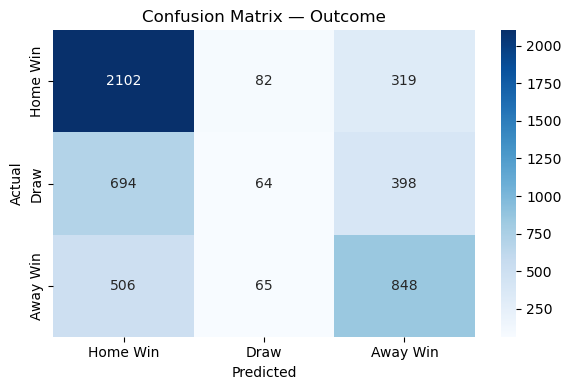

              precision    recall  f1-score   support

    Home Win       0.64      0.84      0.72      2503
        Draw       0.30      0.06      0.09      1156
    Away Win       0.54      0.60      0.57      1419

    accuracy                           0.59      5078
   macro avg       0.49      0.50      0.46      5078
weighted avg       0.53      0.59      0.54      5078



In [8]:
# ============================================================
# CELL 8 — Task 1: Train & Compare Classifiers (Outcome)
# ============================================================
import time
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

classifiers = {
    'Random Forest':  RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boost': GradientBoostingClassifier(n_estimators=200, random_state=42),
    'Logistic Reg':   LogisticRegression(max_iter=1000, random_state=42),
}
if HAS_XGB:
    classifiers['XGBoost'] = XGBClassifier(n_estimators=200, random_state=42, eval_metric='mlogloss', verbosity=0)

clf_results = {}
for name, clf in classifiers.items():
    start = time.time()
    clf.fit(X_train, y_train)
    elapsed = time.time() - start
    acc = accuracy_score(y_test, clf.predict(X_test))
    clf_results[name] = {'model': clf, 'accuracy': acc}
    print(f'{name:20s}: {acc*100:.2f}%  ({elapsed:.1f}s)')

best_clf_name = max(clf_results, key=lambda k: clf_results[k]['accuracy'])
best_clf      = clf_results[best_clf_name]['model']
print(f'\nBest outcome model: {best_clf_name}  ({clf_results[best_clf_name]["accuracy"]*100:.2f}%)')

# Confusion matrix
y_pred = best_clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=['Home Win','Draw','Away Win'],
            yticklabels=['Home Win','Draw','Away Win'], cmap='Blues')
plt.title('Confusion Matrix — Outcome'); plt.ylabel('Actual'); plt.xlabel('Predicted')
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, target_names=['Home Win','Draw','Away Win']))

In [9]:
# ============================================================
# CELL 9 — Task 2: Train & Compare Regressors (Exact Score)
# ============================================================
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error

try:
    from xgboost import XGBRegressor
    HAS_XGB_R = True
except ImportError:
    HAS_XGB_R = False

score_cols = results_sorted[['date','home_team','away_team','home_score','away_score']]
feat_reg   = feat.merge(score_cols, on=['date','home_team','away_team'], how='left')

X_reg  = feat_reg[FEATURES]
y_home = feat_reg['home_score']
y_away = feat_reg['away_score']

idx_train, idx_test = train_test_split(range(len(X_reg)), test_size=0.2, random_state=42)
X_train_r    = X_reg.iloc[idx_train].reset_index(drop=True)
X_test_r     = X_reg.iloc[idx_test].reset_index(drop=True)
y_home_train = y_home.iloc[idx_train].reset_index(drop=True)
y_home_test  = y_home.iloc[idx_test].reset_index(drop=True)
y_away_train = y_away.iloc[idx_train].reset_index(drop=True)
y_away_test  = y_away.iloc[idx_test].reset_index(drop=True)

regressors = {
    'Random Forest':  RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    'Gradient Boost': GradientBoostingRegressor(n_estimators=200, random_state=42),
    'Ridge':          Ridge(),
}
if HAS_XGB_R:
    regressors['XGBoost'] = XGBRegressor(n_estimators=200, random_state=42, verbosity=0)

reg_results = {}
for name, base in regressors.items():
    reg_home = clone(base); reg_away = clone(base)
    reg_home.fit(X_train_r, y_home_train)
    reg_away.fit(X_train_r, y_away_train)
    home_pred = reg_home.predict(X_test_r)
    away_pred = reg_away.predict(X_test_r)
    mae_home  = mean_absolute_error(y_home_test, home_pred)
    mae_away  = mean_absolute_error(y_away_test, away_pred)
    exact_acc = np.mean(
        (np.round(home_pred) == y_home_test.values) &
        (np.round(away_pred) == y_away_test.values)
    )
    reg_results[name] = {'home_model': reg_home, 'away_model': reg_away,
                         'mae_home': mae_home, 'mae_away': mae_away, 'exact_acc': exact_acc}
    print(f'{name:20s}  MAE home={mae_home:.2f}  away={mae_away:.2f}  exact score={exact_acc*100:.1f}%')

best_reg_name = max(reg_results, key=lambda k: reg_results[k]['exact_acc'])
best_reg      = reg_results[best_reg_name]
print(f'\nBest score model: {best_reg_name}  (exact acc = {best_reg["exact_acc"]*100:.1f}%)')

Random Forest         MAE home=1.09  away=0.87  exact score=9.6%
Gradient Boost        MAE home=1.06  away=0.86  exact score=10.3%
Ridge                 MAE home=1.08  away=0.87  exact score=10.1%
XGBoost               MAE home=1.11  away=0.91  exact score=10.2%

Best score model: Gradient Boost  (exact acc = 10.3%)


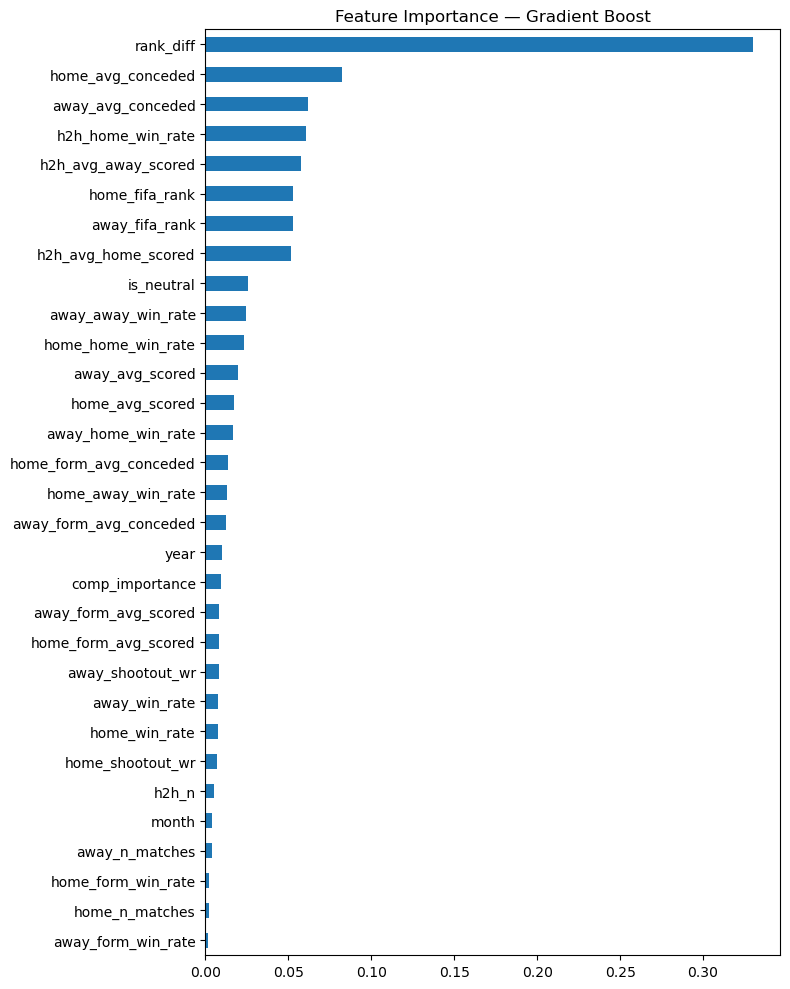

In [10]:
# ============================================================
# CELL 10 — Feature Importance
# ============================================================
if hasattr(best_clf, 'feature_importances_'):
    imp = pd.Series(best_clf.feature_importances_, index=FEATURES).sort_values()
    imp.plot(kind='barh', figsize=(8, 10), title=f'Feature Importance — {best_clf_name}')
    plt.tight_layout(); plt.show()

In [11]:
# ============================================================
# CELL 11 — Save Models (v2)
# ============================================================
import joblib, os

os.makedirs('../dataII', exist_ok=True)
joblib.dump(best_clf,               '../dataII/model_outcome_v2.pkl')
joblib.dump(best_reg['home_model'], '../dataII/model_home_score_v2.pkl')
joblib.dump(best_reg['away_model'], '../dataII/model_away_score_v2.pkl')

print('Saved:')
print(f'  model_outcome_v2.pkl    — {best_clf_name}')
print(f'  model_home_score_v2.pkl — {best_reg_name}')
print(f'  model_away_score_v2.pkl — {best_reg_name}')

Saved:
  model_outcome_v2.pkl    — Gradient Boost
  model_home_score_v2.pkl — Gradient Boost
  model_away_score_v2.pkl — Gradient Boost


In [12]:
# ============================================================
# CELL 12 — Predict Function (updated with new features)
# ============================================================
def predict_match(home_team, away_team, is_neutral=0, tournament='Friendly'):
    today = pd.Timestamp.today()

    h       = team_stats(home_team, today)
    a       = team_stats(away_team, today)
    h_hw, h_aw = team_stats_split(home_team, today)
    a_hw, a_aw = team_stats_split(away_team, today)
    h_fwr, h_fsc, h_fcc = recent_form(home_team, today)
    a_fwr, a_fsc, a_fcc = recent_form(away_team, today)
    h2h     = h2h_stats(home_team, away_team, today)
    home_rank = get_rank(home_team)
    away_rank = get_rank(away_team)

    row = pd.DataFrame([{
        'is_neutral':             is_neutral,
        'year':                   today.year,
        'month':                  today.month,
        'comp_importance':        comp_importance(tournament),
        'home_win_rate':          h['win_rate'],
        'home_avg_scored':        h['avg_scored'],
        'home_avg_conceded':      h['avg_conceded'],
        'home_n_matches':         h['n_matches'],
        'home_shootout_wr':       shootout_win_rate(home_team, today),
        'home_home_win_rate':     h_hw,
        'home_away_win_rate':     h_aw,
        'home_form_win_rate':     h_fwr,
        'home_form_avg_scored':   h_fsc,
        'home_form_avg_conceded': h_fcc,
        'away_win_rate':          a['win_rate'],
        'away_avg_scored':        a['avg_scored'],
        'away_avg_conceded':      a['avg_conceded'],
        'away_n_matches':         a['n_matches'],
        'away_shootout_wr':       shootout_win_rate(away_team, today),
        'away_home_win_rate':     a_hw,
        'away_away_win_rate':     a_aw,
        'away_form_win_rate':     a_fwr,
        'away_form_avg_scored':   a_fsc,
        'away_form_avg_conceded': a_fcc,
        'h2h_home_win_rate':      h2h['h2h_home_win_rate'],
        'h2h_avg_home_scored':    h2h['h2h_avg_home_scored'],
        'h2h_avg_away_scored':    h2h['h2h_avg_away_scored'],
        'h2h_n':                  h2h['h2h_n'],
        'home_fifa_rank':         home_rank,
        'away_fifa_rank':         away_rank,
        'rank_diff':              away_rank - home_rank,
    }])

    outcome   = best_clf.predict(row)[0]
    proba     = best_clf.predict_proba(row)[0]
    home_g    = max(0, int(round(best_reg['home_model'].predict(row)[0])))
    away_g    = max(0, int(round(best_reg['away_model'].predict(row)[0])))
    label     = {0: 'Home Win', 1: 'Draw', 2: 'Away Win'}

    print(f'\n  {home_team}  vs  {away_team}')
    print(f'  Tournament     : {tournament}  (importance={comp_importance(tournament)})')
    print(f'  Venue          : {"Neutral" if is_neutral else home_team + " home ground"}')
    print(f'  FIFA Ranks     : {home_team} #{home_rank}  vs  {away_team} #{away_rank}')
    print(f'  Predicted Score: {home_team} {home_g} - {away_g} {away_team}')
    print(f'  Outcome        : {label[outcome]}')
    print(f'  {home_team} win  : {proba[0]*100:.1f}%')
    print(f'  Draw           : {proba[1]*100:.1f}%')
    print(f'  {away_team} win  : {proba[2]*100:.1f}%')

In [17]:
predict_match('Norway', 'Senegal', is_neutral=1, tournament='FIFA World Cup')
# predict_match('France', 'England',   is_neutral=1, tournament='FIFA World Cup')
# predict_match('USA',    'Germany',   is_neutral=0, tournament='FIFA World Cup')


  Norway  vs  Senegal
  Tournament     : FIFA World Cup  (importance=4)
  Venue          : Neutral
  FIFA Ranks     : Norway #46.0  vs  Senegal #18.0
  Predicted Score: Norway 1 - 1 Senegal
  Outcome        : Home Win
  Norway win  : 37.7%
  Draw           : 28.4%
  Senegal win  : 33.9%
